# Problem set 2

**(2-1)** First, use python as a calculator. 

**(a)** Suppose the Earth behaves as a blackbody radiator with effective global mean emission temperature $T_e$. Stefan's law indicates that the total outgoing longwave radiation emitted to space is:

$\mathrm{OLR} = \sigma_\mathrm{B} T_e^4$

where $\sigma_\mathrm{B} = 5.67 \times 10^{-8}\,\mathrm{W}\,\mathrm{m}^{-2}\,\mathrm{K}^{-4}$ is the Stefan-Boltzmann constant. The observed annual mean value for OLR is $239\,\mathrm{W}\,\mathrm{m}^{-2}$. Use the following code block to calculate the effective emission temperature $T_e$. 

In [1]:
import numpy as np

sigma_B = 5.67e-8  # W m^-2 K^ -4
OLR = 239.0        # W m^-2

T_e = np.power((OLR / sigma_B), 0.25)
print(f"Effective emission temperature: {T_e:.2f} K")

Effective emission temperature: 254.80 K


**(b)** Is the Stefan-Boltzmann constant available in numpy, like with numpy.pi? Can you find another module that provides it?

No, NumPy does not provide the Stefan–Boltzmann constant as a built-in constant like `numpy.pi`.

A common source is `scipy.constants`, where it is available as `Stefan_Boltzmann`.

In [2]:
import numpy as np
from scipy import constants as const

print(f"numpy has 'Stefan_Boltzmann': {hasattr(np, 'Stefan_Boltzmann')}")
print(f"Stefan-Boltzmann constant from scipy.constants: {const.Stefan_Boltzmann} W m^-2 K^-4")
print(f"scipy's constant close to our defined sigma_B: {np.isclose(const.Stefan_Boltzmann, sigma_B)}")

numpy has 'Stefan_Boltzmann': False
Stefan-Boltzmann constant from scipy.constants: 5.6703744191844314e-08 W m^-2 K^-4
scipy's constant close to our defined sigma_B: True


**(2-2)** Planck’s law relates the intensity of radiation emitted by a black body to its temperature. The equation for [spectral radiance](https://physics.info/planck/) in terms of wavelength is:

$(\lambda,T) = \frac{2 h c^2}{\lambda^5} \frac{1}{\exp \left ( \frac{h c}{\lambda k_\mathrm{B} T} \right ) - 1}$

where $h = 6.625 \times 10^{-34}$ J s is the Planck constant, $c = 3 \times 10^8\,\mathrm{m}\,\mathrm{s}^{-1}$ is the speed of light, and $k_\mathrm{B} = 1.38 \times 10^{-23}\,\mathrm{J}\,\mathrm{K}^{-1}$ is the Boltzmann constant.

**(a)** Write a function that takes an array of wavelengths $\lambda$ and a single temperature $T$ and returns an array of intensities $B(\lambda, T)$. Be careful of units!

In [3]:
import numpy as np

def planck_lambda(wavelength: np.ndarray, temperature: float) -> np.ndarray:
    """Return spectral radiance B(λ, T) for wavelength(s) in meters."""
    h = 6.625e-34      # J s
    c = 3.0e8          # m s^-1
    k_B = 1.38e-23     # J K^-1

    exponent = h * c / (wavelength * k_B * temperature)
    return (2 * h * c**2) / (wavelength**5) / (np.exp(exponent) - 1)

**(b)** Use this function to calculate distributions of emission intensity by wavelength for black bodies of 6000 K and 255 K. Plot these distributions as a function of wavelength in a single panel (you may have to get creative, since the maxima are very different between the two distributions).

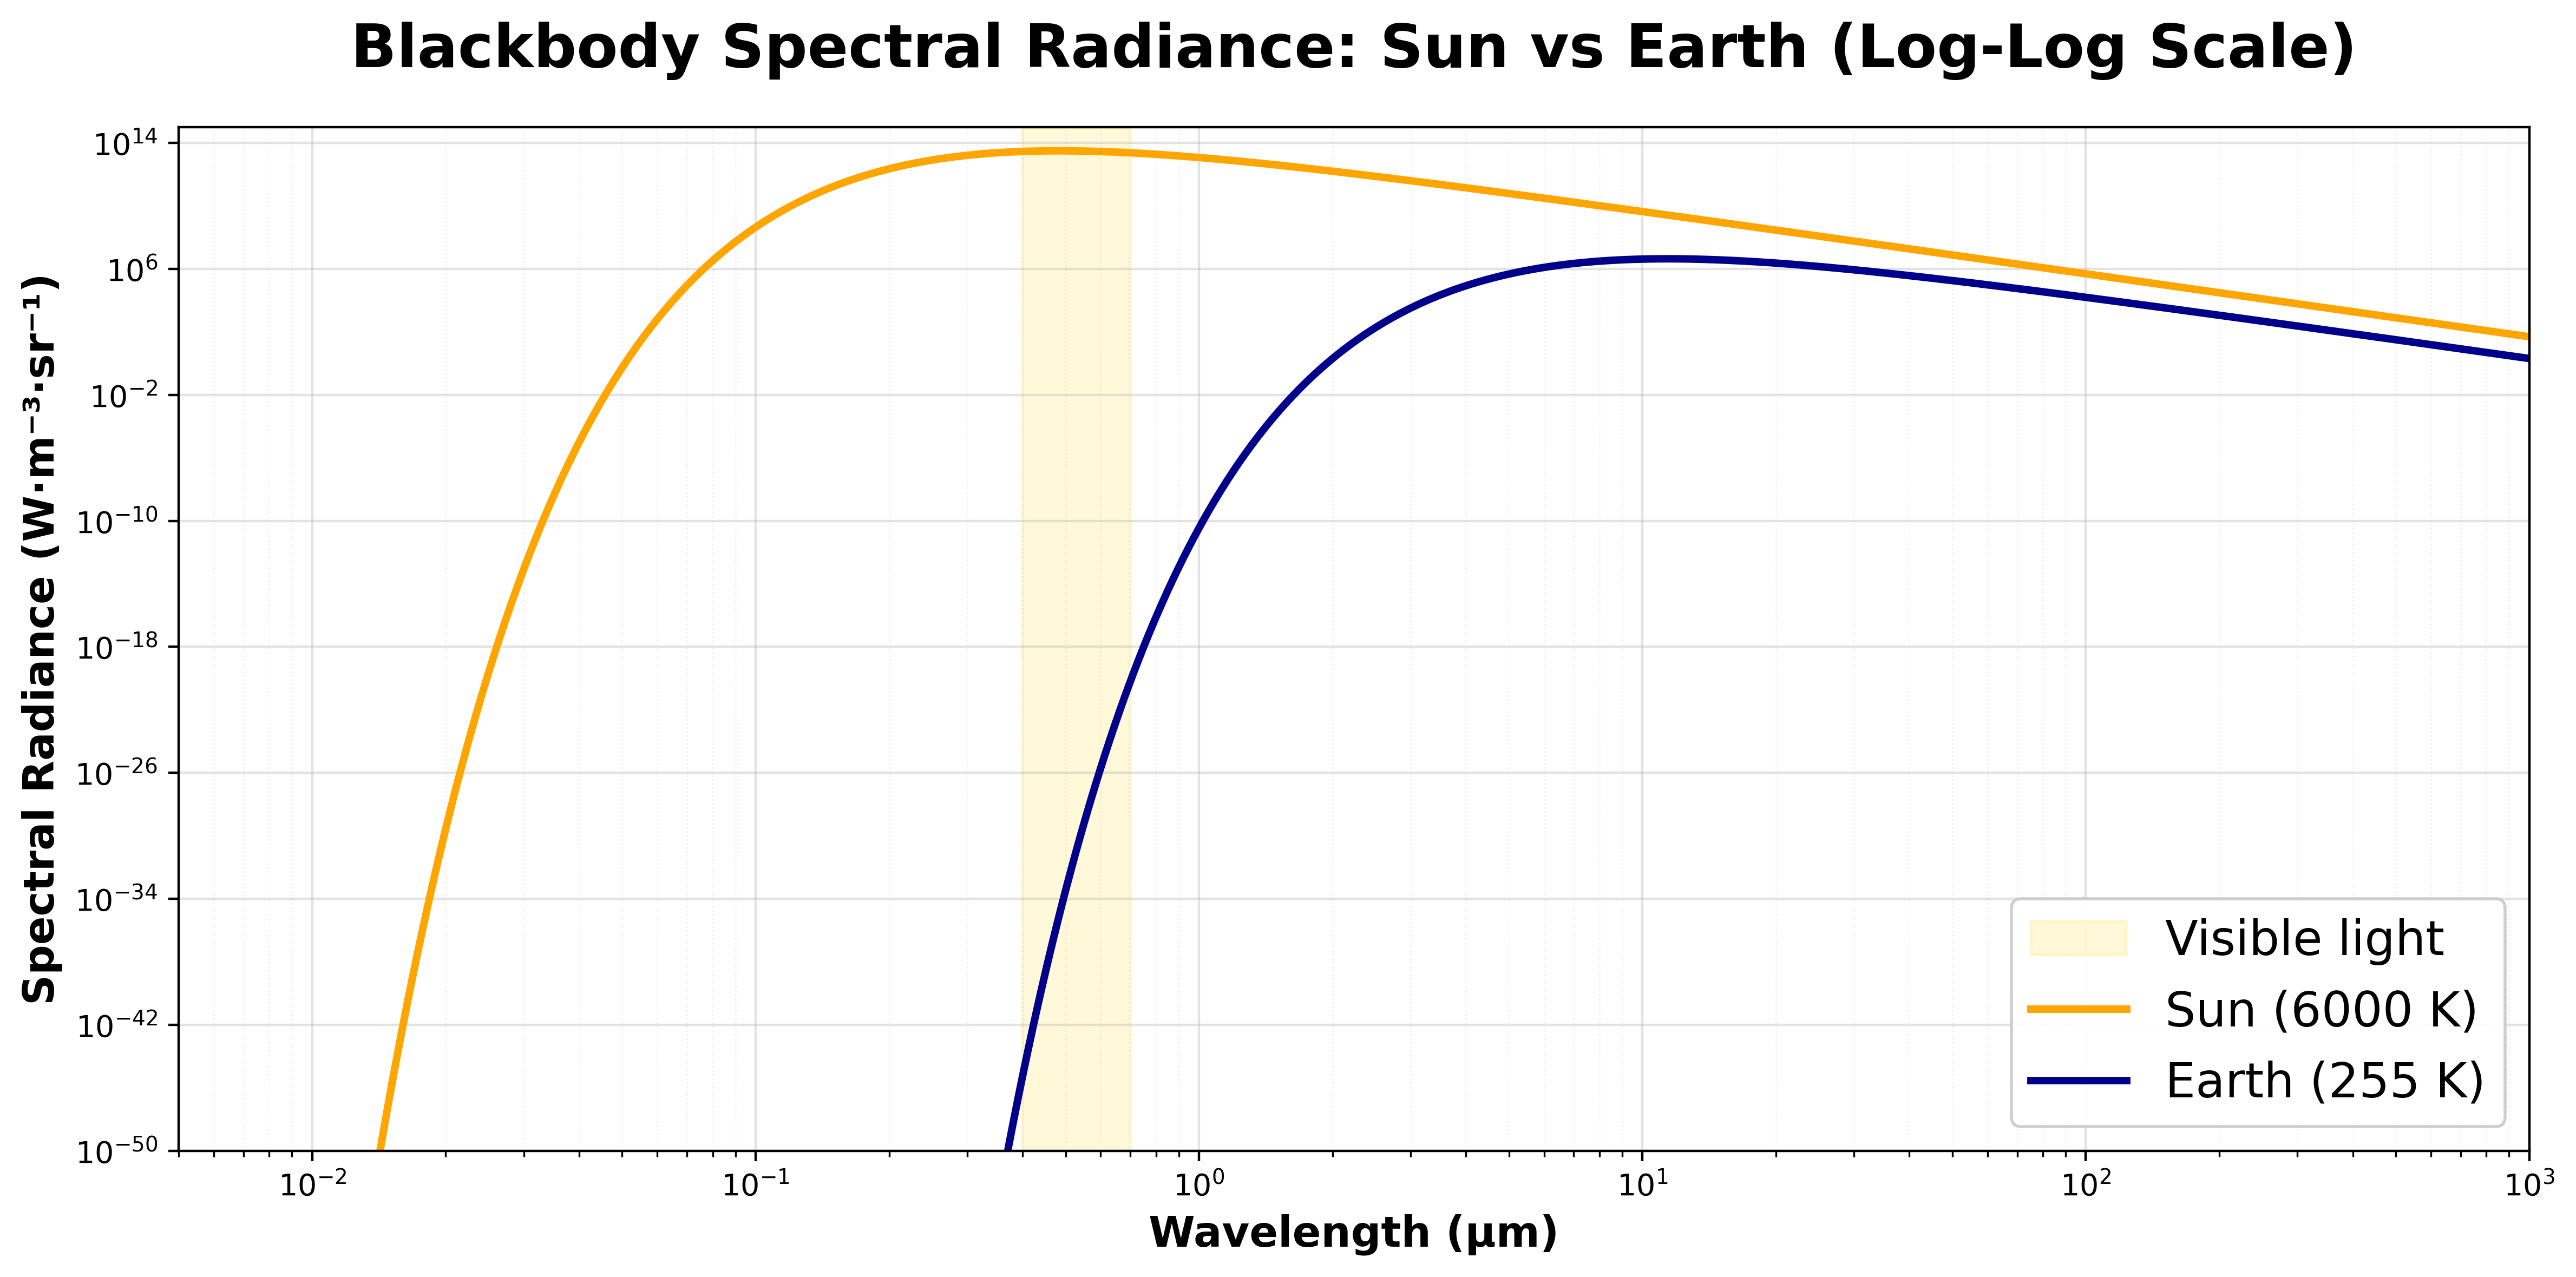

In [ ]:
import matplotlib.pyplot as plt

wavelength_6000_μm = np.logspace(-2, 3, 10000)   # μm
wavelength_255_μm = np.logspace(-0.5, 3, 10000)  # μm


wavelength_6000_m = wavelength_6000_μm * 1e-6  # convert μm to m
wavelength_255_m = wavelength_255_μm * 1e-6    # convert μm to m

B_6000 = planck_lambda(wavelength_6000_m, 6000)
B_255 = planck_lambda(wavelength_255_m, 255)

fig, ax = plt.subplots(figsize=(12, 6), dpi=400)

# Highlight visible-light band (0.4–0.7 μm)
ax.axvspan(0.4, 0.7, alpha=0.15, color="gold", label="Visible light")

ax.loglog(wavelength_6000_μm, B_6000, label="Sun (6000 K)", color="orange", linewidth=2.5)
ax.loglog(wavelength_255_μm, B_255, label="Earth (255 K)", color="darkblue", linewidth=2.5)

ax.set_xlabel("Wavelength (μm)", fontsize=14, fontweight="bold")
ax.set_ylabel("Spectral Radiance (W·m⁻³·sr⁻¹)", fontsize=14, fontweight="bold")
ax.set_title("Blackbody Spectral Radiance: Sun vs Earth (Log-Log Scale)", fontsize=20, fontweight="bold", pad=20)
ax.set_xlim(0.005, 1000)
ax.set_ylim(1e-50, 1e15)


ax.grid(True, which="major", ls="-", alpha=0.35, linewidth=0.8)
ax.grid(True, which="minor", ls=":", alpha=0.2, linewidth=0.5)
ax.legend(loc="lower right", fontsize=16, framealpha=0.95)
W
plt.tight_layout()
plt.show()

**Extra credit:** rewrite your function using lists instead of numpy arrays. 

In [5]:
import math

def planck_lambda_list(wavelength: list[float], temperature: float) -> list[float]:
    """List-based version of Planck spectral radiance."""
    h = 6.625e-34      # J s
    c = 3.0e8          # m s^-1
    k_B = 1.38e-23     # J K^-1

    return [(2 * h * c**2) / (lam**5) / (math.exp(h * c / (lam * k_B * temperature)) - 1) for lam in wavelength]

In [6]:
import numpy as np
sample = [1e-6, 2e-6, 5e-6, 1e-5]  # in meters

test = np.allclose(np.array(planck_lambda_list(sample, 255)), planck_lambda(np.array(sample), 255))
print(f"Comparing list-based and array-based Planck calculations: {test}")

Comparing list-based and array-based Planck calculations: True
